# Wavefront and atmosphere

**Scientific question.** What does a single frozen-flow von Kármán turbulence
realization look like across a telescope pupil, and how do the two ways the
library represents an aberration — optical path difference (OPD, in metres)
and phase (in radians at a reference wavelength) — relate to each other?

This tutorial uses only installed `shwfs_ao` APIs. It builds a pupil, draws one
seeded atmospheric screen, and confirms the phase/OPD conversion is an exact
inverse pair.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
    SPECTRUM_SUBHARMONIC_V2,
    TRANSLATION_FOURIER_SUBPIXEL_V2,
    von_karman_piston_removed_variance_rad2,
)
from shwfs_ao.core.geometry import build_pupil_geometry
from shwfs_ao.core.wavefront import masked_rms, opd_to_phase, phase_to_opd

SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
PUPIL_PIXELS = 96
REFERENCE_WAVELENGTH_M = 500e-9

Matplotlib is building the font cache; this may take a moment.


## Configuration

In [2]:
pupil = build_pupil_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
)
config = FrozenFlowAtmosphereConfig(
    grid_size=PUPIL_PIXELS,
    screen_grid_size=3 * PUPIL_PIXELS,
    spectrum_model=SPECTRUM_SUBHARMONIC_V2,
    translation_model=TRANSLATION_FOURIER_SUBPIXEL_V2,
    normalize_rms=False,
    delta_m=pupil.pixel_spacing_xy_m[0],
    pupil_diameter_m=TELESCOPE_DIAMETER_M,
    r0_m=0.15,
    outer_scale_m=25.0,
    wind_m_per_s=(8.0, 0.0),
    root_seed=SEED,
)
config


FrozenFlowAtmosphereConfig(grid_size=96, delta_m=0.021052631578947323, pupil_diameter_m=2.0, r0_m=0.15, outer_scale_m=25.0, phase_reference_wavelength_m=5e-07, wind_m_per_s=(8.0, 0.0), root_seed=20240517, target_rms_rad=None, normalize_rms=False, spectrum_model='subharmonic_von_karman_v2', translation_model='fourier_subpixel_v2', screen_grid_size=288)

## Simulation call

In [3]:
atmosphere = FrozenFlowAtmosphere(config, pupil_mask=pupil.pupil_mask)
atmosphere.reset(realization_index=0)
opd_m = atmosphere.opd_at(0.0)
phase_rad = opd_to_phase(opd_m, REFERENCE_WAVELENGTH_M)
opd_roundtrip_m = phase_to_opd(phase_rad, REFERENCE_WAVELENGTH_M)
assert atmosphere.metadata["absolutely_normalized"]
assert not atmosphere.metadata["realization_rms_rescaled"]
np.testing.assert_allclose(opd_roundtrip_m[pupil.pupil_mask], opd_m[pupil.pupil_mask], atol=1e-18, rtol=1e-12)


## Diagnostic table

In [4]:
import pandas as pd

opd_rms_m = masked_rms(opd_m, pupil.pupil_mask)
ensemble_phase_rms_rad = np.sqrt(von_karman_piston_removed_variance_rad2(
    TELESCOPE_DIAMETER_M, config.r0_m, config.outer_scale_m
))
ensemble_opd_rms_m = ensemble_phase_rms_rad * REFERENCE_WAVELENGTH_M / (2 * np.pi)
table = pd.DataFrame(
    [
        ("Fried parameter r0", config.r0_m, "m"),
        ("Outer scale L0", config.outer_scale_m, "m"),
        ("D / r0", TELESCOPE_DIAMETER_M / config.r0_m, "-"),
        ("sqrt(ensemble mean OPD variance)", ensemble_opd_rms_m * 1e9, "nm"),
        ("sqrt(ensemble mean phase variance)", ensemble_phase_rms_rad, "rad"),
        ("Seeded screen OPD RMS", opd_rms_m * 1e9, "nm"),
        ("Seeded screen phase RMS", masked_rms(phase_rad, pupil.pupil_mask), "rad"),
        (
            "Phase/OPD round-trip max error",
            float(np.nanmax(np.abs(opd_roundtrip_m - opd_m))),
            "m",
        ),
    ],
    columns=["quantity", "value", "units"],
)
table

,quantity,value,units
0,Fried parameter r0,1.500000e-01,m
1,Outer scale L0,2.500000e+01,m
2,D / r0,1.333333e+01,-
3,sqrt(ensemble mean OPD variance),4.832568e+02,nm
4,sqrt(ensemble mean phase variance),6.072783e+00,rad
5,Seeded screen OPD RMS,5.874735e+02,nm
6,Seeded screen phase RMS,7.382410e+00,rad
7,Phase/OPD round-trip max error,2.117582e-22,m


## Plot

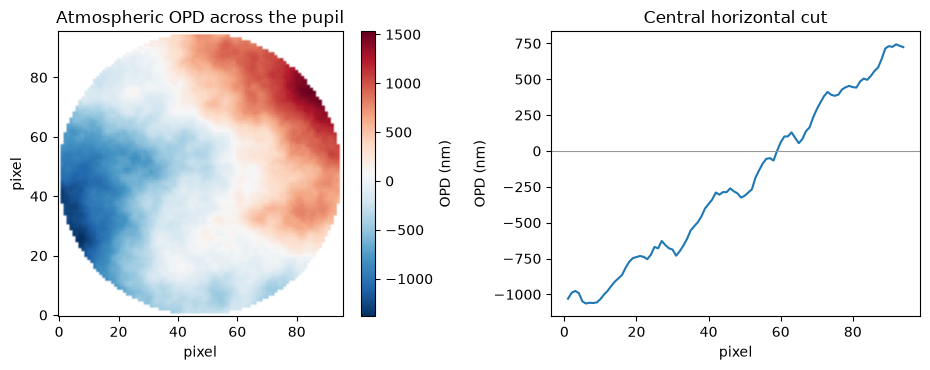

In [5]:
display_opd = np.where(pupil.pupil_mask, opd_m, np.nan) * 1e9
figure, (left, right) = plt.subplots(1, 2, figsize=(9.5, 3.8))
image = left.imshow(display_opd, origin="lower", cmap="RdBu_r")
left.set_title("Atmospheric OPD across the pupil")
left.set_xlabel("pixel")
left.set_ylabel("pixel")
figure.colorbar(image, ax=left, label="OPD (nm)")
mid_row = display_opd[PUPIL_PIXELS // 2]
right.plot(np.arange(PUPIL_PIXELS), mid_row, color="C0")
right.axhline(0.0, color="0.6", linewidth=0.8)
right.set_title("Central horizontal cut")
right.set_xlabel("pixel")
right.set_ylabel("OPD (nm)")
figure.tight_layout()
plt.show()

## Interpretation

The v2 screen carries the amplitude specified by `r0` and the finite outer
scale. For `D = 2 m`, `r0 = 0.15 m`, and `L0 = 25 m`, the circular-pupil theory
predicts about **483 nm for the square root of ensemble mean OPD variance**.
The seeded screen has its own RMS and need not equal that ensemble quantity:
`normalize_rms=False` preserves realization-to-realization scatter. The
infinite-outer-scale Kolmogorov value would be larger and is not the target for
this configuration.

Phase and OPD describe the same disturbance in different units. Their
round-trip difference is at numerical precision.

## Limitations

- One realization cannot validate an ensemble amplitude or modal distribution.
- Finite spatial bandwidth and spectral quadrature approximate the continuum
  covariance; the v2 model does not pin individual pupil RMS values.
- A padded screen and exact spectral translation support the configured
  finite travel range; this single layer does not model boiling or a full
  atmospheric profile.
- The outer scale and `r0` are illustrative, not fitted to a site.
